##Modelo de Classificação

Treinar um modelo preditivo de classificação utilizando o algoritmo Regressão Logística (Logistic Regression do sklearn) para prever se a rede elétrica está estável ou instável com base nos atributos fornecidos na fonte abaixo:

https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

In [ ]:
#Preparação do ambiente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Agoritimo de regressão logística
from sklearn.linear_model import LogisticRegression
#Função que permite separação dos dados de treino e teste
from sklearn.model_selection import train_test_split
#Métricas paea classificação
from sklearn.metrics import accuracy_score
#Matriz de confusão
from sklearn.metrics import confusion_matrix

In [ ]:
#Carregar os dados e criar dataframe
dados = pd.read_csv('https://raw.githubusercontent.com/Isa-souza07/Checkpoint_2-Modelo-de-Classificacao-com-Dados-de-Energia/refs/heads/main/Data_for_UCI_named.csv')
dados.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [ ]:
dados.shape #tamanho da base em linhas e colunas

(10000, 14)

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [ ]:
dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [ ]:
#Estatísticas descritivas
#Somente atributos categóricos
dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [ ]:
#Classses que existem no atributo 'stabf'
dados['stabf'].unique() #duas classes, rede estável e instável

array(['unstable', 'stable'], dtype=object)

In [ ]:
#Quantos registros temos de cada classe em 'stabf'
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [ ]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [ ]:
#Dados de entrada X ---> Features ---> Dataframe
#Variáveis independentes
X = dados.drop(['stab', 'stabf'], axis=1)
X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [ ]:
dados['stabf'] = dados['stabf'].replace({'unstable': "INSTÁVEL", 'stable': 'ESTÁVEL'})

In [ ]:
dados['stabf'].value_counts()

,count
stabf,
INSTÁVEL,6380
ESTÁVEL,3620


In [ ]:
#Dados de saída y ---> Target ---> O que vamos prever
#Variável dependente
y = dados['stabf']
y

,stabf
0,INSTÁVEL
1,ESTÁVEL
2,INSTÁVEL
3,INSTÁVEL
4,INSTÁVEL
...,...
9995,INSTÁVEL
9996,ESTÁVEL
9997,ESTÁVEL
9998,INSTÁVEL


In [ ]:
#Separação de dados para treino e para teste (train_test_split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X.shape[0]

10000

In [ ]:
X_train.shape[0]

7000

In [ ]:
X_test.shape[0]

3000

In [ ]:
y.shape[0]

10000

In [ ]:
y_train.shape[0]

7000

In [ ]:
y_test.shape[0]

3000

In [ ]:
#Instanciando o modelo com base no algoritmo Logistic Regression
modelo = LogisticRegression()

In [ ]:
#Treinando o modelo
modelo.fit(X_train, y_train)

LogisticRegression()

In [ ]:
#Gerando as probabilidades
probabilidades = modelo.predict_proba(X_test)
probabilidades[:50]

array([[0.04832458, 0.95167542],
       [0.06765984, 0.93234016],
       [0.32851224, 0.67148776],
       [0.9774269 , 0.0225731 ],
       [0.63944896, 0.36055104],
       [0.57932851, 0.42067149],
       [0.75220971, 0.24779029],
       [0.0253573 , 0.9746427 ],
       [0.0491907 , 0.9508093 ],
       [0.75081851, 0.24918149],
       [0.0574757 , 0.9425243 ],
       [0.45204514, 0.54795486],
       [0.56012373, 0.43987627],
       [0.2390839 , 0.7609161 ],
       [0.01632351, 0.98367649],
       [0.25307423, 0.74692577],
       [0.44524977, 0.55475023],
       [0.1910339 , 0.8089661 ],
       [0.43188331, 0.56811669],
       [0.33936356, 0.66063644],
       [0.08175104, 0.91824896],
       [0.12786239, 0.87213761],
       [0.19940876, 0.80059124],
       [0.76364784, 0.23635216],
       [0.32962162, 0.67037838],
       [0.30896806, 0.69103194],
       [0.62552247, 0.37447753],
       [0.46526131, 0.53473869],
       [0.70576222, 0.29423778],
       [0.9237145 , 0.0762855 ],
       [0.

In [ ]:
#Gerando as previsões
y_predict = modelo.predict(X_test)
y_predict[:50]

array(['INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'INSTÁVEL',
       'INSTÁVEL', 'INSTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL',
       'INSTÁVEL', 'ESTÁVEL', 'INSTÁVEL', 'ESTÁVEL', 'ESTÁVEL'],
      dtype=object)

In [ ]:
#Acurácia do modelo
acuracia = 100*accuracy_score(y_test, y_predict)
print(f'Acurácia do modelo é de: {acuracia:.2f}%')

Acurácia do modelo é de: 80.77%


In [ ]:
#Gerar matriz de confusão com matplotlib e hetamap
matriz_confusao = confusion_matrix(y_test, y_predict)
matriz_confusao

array([[ 748,  313],
       [ 264, 1675]])

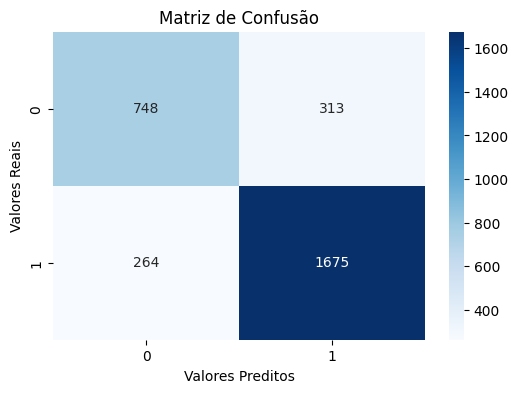

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Valores Preditos')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()